In [1]:
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
import seaborn as sn
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from sklearn import neighbors
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


# Read and print CV data for the first few rows
df = pd.read_csv("email_spamData.csv")
df.head()


,label,subject,email_to,email_from,message
0,1,"Generic Cialis, branded quality@",the00@speedy.uwaterloo.ca,"""Tomas Jacobs"" <RickyAmes@aol.com>",Content-Type: text/html;\nContent-Transfer-Enc...
1,0,Typo in /debian/README,debian-mirrors@lists.debian.org,Yan Morin <yan.morin@savoirfairelinux.com>,"Hi, i've just updated from the gulus and I che..."
2,1,authentic viagra,<the00@plg.uwaterloo.ca>,"""Sheila Crenshaw"" <7stocknews@tractionmarketin...","Content-Type: text/plain;\n\tcharset=""iso-8859..."
3,1,Nice talking with ya,opt4@speedy.uwaterloo.ca,"""Stormy Dempsey"" <vqucsmdfgvsg@ruraltek.com>","Hey Billy, \n\nit was really fun going out the..."
4,1,or trembling; stomach cramps; trouble in sleep...,ktwarwic@speedy.uwaterloo.ca,"""Christi T. Jernigan"" <dcube@totalink.net>",Content-Type: multipart/alternative;\n ...


In [2]:
# cheking data types
print("checking data types : \n")
print(df.dtypes)

# checking columns and rows 
print("\nrows and columns \n" , df.shape)

# checking for null values
print("\nIt appears we have some null values\n")
print(df.isnull().sum())



checking data types : 

label          int64
subject       object
email_to      object
email_from    object
message       object
dtype: object

rows and columns 
 (75419, 5)

It appears we have some null values

label            0
subject        793
email_to       576
email_from       0
message       1487
dtype: int64


In [3]:
# dropping rows we dont need 

df = df.drop(['message'], axis=1)

#dropp rows with missing values
df = df.dropna()   

df.head()

,label,subject,email_to,email_from
0,1,"Generic Cialis, branded quality@",the00@speedy.uwaterloo.ca,"""Tomas Jacobs"" <RickyAmes@aol.com>"
1,0,Typo in /debian/README,debian-mirrors@lists.debian.org,Yan Morin <yan.morin@savoirfairelinux.com>
2,1,authentic viagra,<the00@plg.uwaterloo.ca>,"""Sheila Crenshaw"" <7stocknews@tractionmarketin..."
3,1,Nice talking with ya,opt4@speedy.uwaterloo.ca,"""Stormy Dempsey"" <vqucsmdfgvsg@ruraltek.com>"
4,1,or trembling; stomach cramps; trouble in sleep...,ktwarwic@speedy.uwaterloo.ca,"""Christi T. Jernigan"" <dcube@totalink.net>"


In [4]:
# check the data again for null values
print("check for null values : \n")
print(df.isnull().sum())

print(df.shape)

print(df.columns)

check for null values : 

label         0
subject       0
email_to      0
email_from    0
dtype: int64
(74208, 4)
Index(['label', 'subject', 'email_to', 'email_from'], dtype='object')


In [5]:
label_encoder = LabelEncoder()
df['subject'] = label_encoder.fit_transform(df['subject'])
df['email_to'] = label_encoder.fit_transform(df['email_to'])
df['email_from'] = label_encoder.fit_transform(df['email_from'])

print(df.dtypes)
df.head()

label         int64
subject       int32
email_to      int32
email_from    int32
dtype: object


,label,subject,email_to,email_from
0,1,6152,9138,29713
1,0,20776,5701,45067
2,1,27818,3946,27352
3,1,10371,8740,28271
4,1,29983,8478,6112


In [6]:
# independat variable X
X = df.drop('label', axis = 1)

# Our descriptive feature
# print (X.describe())
print (X.info())
print (X.shape)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 74208 entries, 0 to 75418
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   subject     74208 non-null  int32
 1   email_to    74208 non-null  int32
 2   email_from  74208 non-null  int32
dtypes: int32(3)
memory usage: 1.4 MB
None
(74208, 3)


In [7]:
# target variable y 


y = df['label']

print (y.describe())
print (y.shape)

count    74208.000000
mean         0.660495
std          0.473545
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: label, dtype: float64
(74208,)


In [8]:
# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Display the head of the scaled data
print(pd.DataFrame(X_train, columns=X.columns).head())


    subject  email_to  email_from
0  0.815744 -0.670709    0.293663
1 -0.686327  1.040785    1.054038
2  0.526280 -0.783925    0.616320
3  0.651606  1.288800    0.310050
4 -1.024145 -1.667313   -0.019581


In [9]:
# Statistics and plots: 

print("Data Statistics:")
print(df.describe())

Data Statistics:
              label       subject      email_to    email_from
count  74208.000000  74208.000000  74208.000000  74208.000000
mean       0.660495  14273.714492   5722.878072  27031.766144
std        0.473545   9222.227458   2638.227550  14327.069457
min        0.000000      0.000000      0.000000      0.000000
25%        0.000000   5697.750000   3771.000000  14263.000000
50%        1.000000  13473.500000   5266.000000  29706.000000
75%        1.000000  21112.000000   8550.000000  39775.000000
max        1.000000  33410.000000   9311.000000  46177.000000


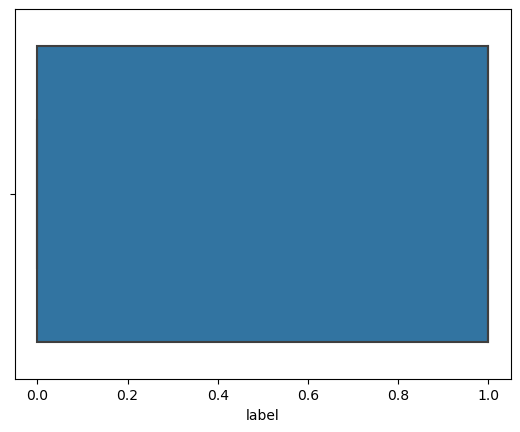

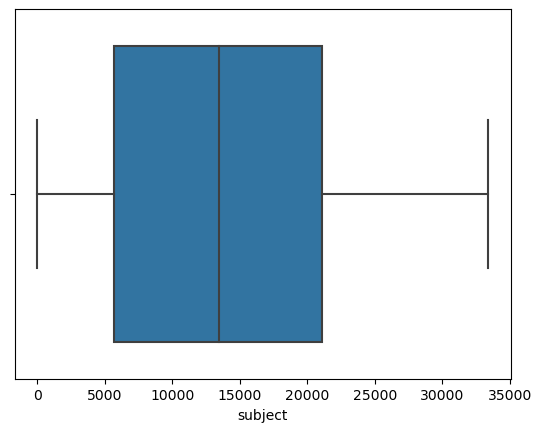

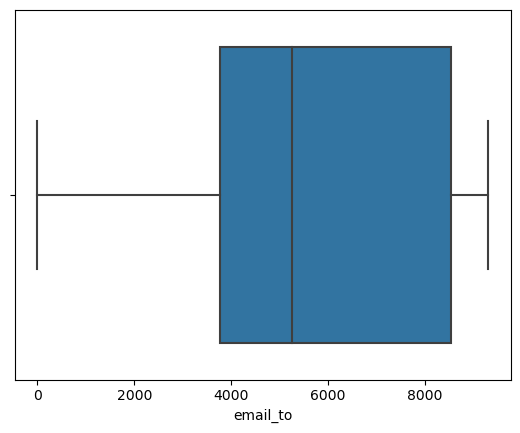

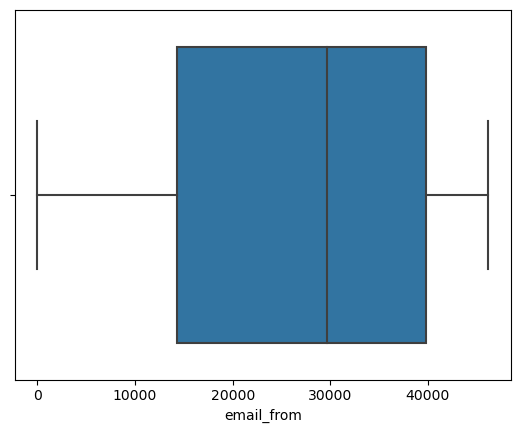

In [10]:
# Visualsing data (not sure if box plots are needed for this problem but i added just incase): 

import seaborn as sns
import matplotlib.pyplot as plt

for column in df:
    plt.figure()
    sns.boxplot(x=df[column])

In [11]:
# Knn
def knn_hyperparameter_tuning(X_train, y_train, X_test, y_test, dmetric, w):
    all_results = []
    for k_value in range(1, 101):
        knn = neighbors.KNeighborsClassifier(n_neighbors=k_value, metric=dmetric, weights=w)
        knn = knn.fit(X_train, y_train)
        accuracy = knn.score(X_test, y_test)
        all_results.append(accuracy)
        print(k_value, accuracy)

    plt.plot(all_results)
    plt.title(f'Accuracy for {dmetric} distance metric, {w} weights')
    plt.xlabel('k Value')
    plt.ylabel('Accuracy')
    plt.show()

1 0.9698153887616224
2 0.9600458159277725
3 0.9679288505592238
4 0.9638862686969412
5 0.9638188923325698
6 0.9610564613933432
7 0.9612585904864573
8 0.9603826977496295
9 0.958698288640345
10 0.9576876431747743
11 0.9570812558954319
12 0.956744374073575
13 0.957822395903517
14 0.9558011049723757
15 0.9557337286080043
16 0.9549925885999192
17 0.9545883304136908
18 0.953712437676863
19 0.952836544940035
20 0.9518932758388358
21 0.9522301576606926
22 0.9524322867538068
23 0.9516237703813503
24 0.9512195121951219
25 0.9506131249157795
26 0.949804608543323
27 0.9493329739927233
28 0.9487939630777523
29 0.9485244576202668
30 0.9479180703409245
31 0.946772672146611
32 0.9466379194178682
33 0.9457620266810403
34 0.9448861339442124
35 0.944818757579841
36 0.9446840048510983
37 0.9423932084624713
38 0.9417194448187576
39 0.9411804339037866
40 0.939832906616359
41 0.9401024120738445
42 0.9394286484301307
43 0.9397655302519876
44 0.9392265193370166
45 0.939293895701388
46 0.9390917666082739
47 0.93

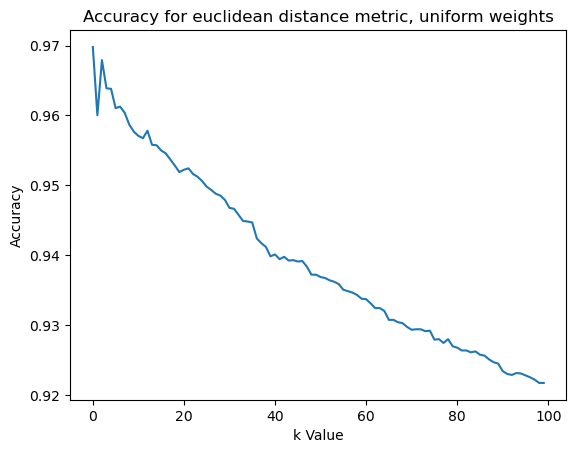

In [12]:
# Perform hyperparameter tuning
# eclidean uniform
knn_hyperparameter_tuning(X_train, y_train, X_test, y_test, "euclidean", "uniform")


1 0.9732515833445627
2 0.9650990432556259
3 0.9703543996765934
4 0.9667834523649104
5 0.9663791941786821
6 0.9659075596280825
7 0.9654359250774828
8 0.964223150518798
9 0.9635493868750842
10 0.9633472577819701
11 0.9628756232313704
12 0.9617976014014283
13 0.9623366123163994
14 0.961730225037057
15 0.9613259668508287
16 0.9612585904864573
17 0.9601131922921439
18 0.9598436868346584
19 0.9591025468265733
20 0.9580245249966312
21 0.9574181377172888
22 0.9570812558954319
23 0.9563401158873467
24 0.9564074922517181
25 0.9565422449804608
26 0.9561379867942326
27 0.9555989758792616
28 0.9557337286080043
29 0.9556663522436329
30 0.9551947176930333
31 0.9544535776849481
32 0.9533081794906347
33 0.9529039213044064
34 0.9524996631181781
35 0.9515563940169789
36 0.9512868885594933
37 0.9502088667295513
38 0.9492655976283519
39 0.9483897048915241
40 0.9477833176121816
41 0.9474464357903247
42 0.9472443066972106
43 0.946772672146611
44 0.9459641557741544
45 0.9458294030454116
46 0.9463684139603827


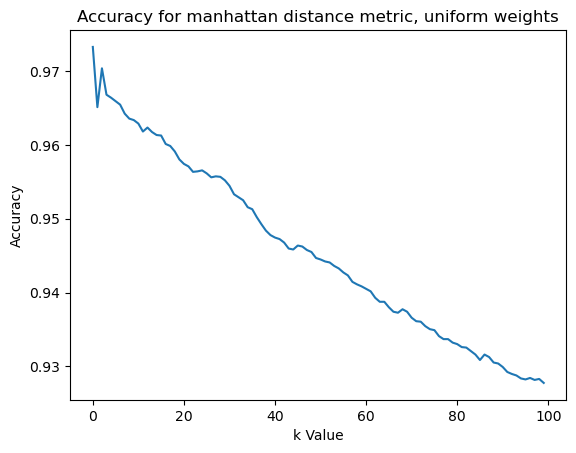

In [13]:
# manhattan uniform
knn_hyperparameter_tuning(X_train, y_train, X_test, y_test, "manhattan", "uniform")


1 0.9732515833445627
2 0.9732515833445627
3 0.9742622288101334
4 0.9742622288101334
5 0.9737905942595337
6 0.9737232178951624
7 0.973655841530791
8 0.9733863360733055
9 0.9726451960652204
10 0.9730494542514486
11 0.9727125724295917
12 0.9720388087858779
13 0.9723083142433634
14 0.9724430669721061
15 0.9723756906077348
16 0.9723756906077348
17 0.9721061851502493
18 0.9719040560571351
19 0.971701926964021
20 0.9716345505996496
21 0.97116291604905
22 0.9709607869559359
23 0.9710281633203073
24 0.970826034227193
25 0.970287023312222
26 0.9700175178547366
27 0.9697480123972511
28 0.9694785069397656
29 0.9694111305753942
30 0.9696132596685083
31 0.9694785069397656
32 0.9692763778466514
33 0.9690742487535372
34 0.9688721196604231
35 0.9686026142029376
36 0.9688721196604231
37 0.9688721196604231
38 0.968669990567309
39 0.9683331087454521
40 0.9688721196604231
41 0.9685352378385662
42 0.968669990567309
43 0.9682657323810807
44 0.9679288505592238
45 0.9676593451017383
46 0.9673898396442528
47 0.

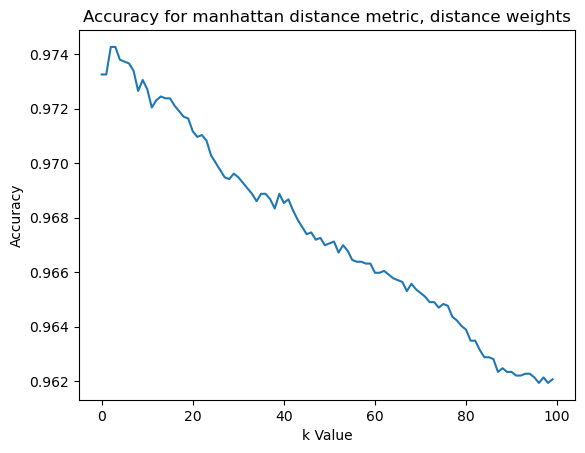

In [14]:
# manhattan distance
knn_hyperparameter_tuning(X_train, y_train, X_test, y_test, "manhattan", "distance")

Accuracy: 0.7410726317207923


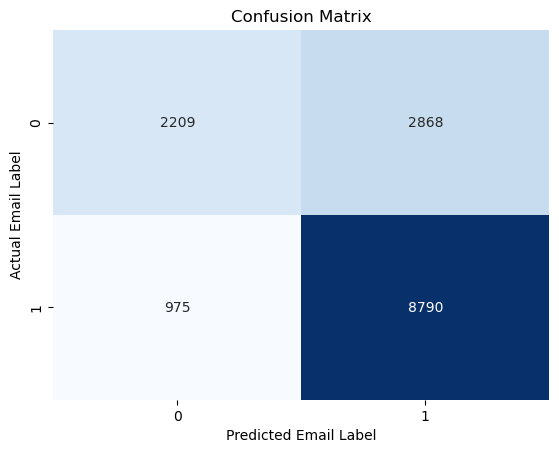

In [15]:
# Logistic Regression

import seaborn as sns
# Create logistic regression model
logreg = LogisticRegression(solver='liblinear')

# Train the model
logreg.fit(X_train, y_train)

# Make predictions on the test set
predictions = logreg.predict(X_test)

# Evaluate the model
accuracy = metrics.accuracy_score(y_test, predictions)
print('Accuracy:', accuracy)

# Plot confusion matrix heatmap
confusion_matrix = metrics.confusion_matrix(y_test, predictions)
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Email Label')
plt.ylabel('Actual Email Label')
plt.title('Confusion Matrix')
plt.show()



Accuracy:  0.7410726317207923


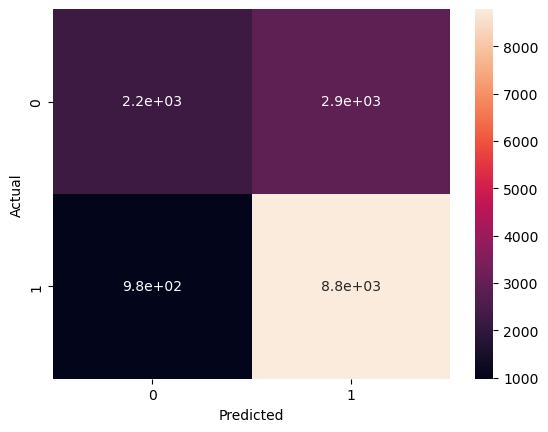

In [16]:
confusion_matrix = pd.crosstab(y_test, predictions, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(confusion_matrix, annot=True)

print('Accuracy: ',metrics.accuracy_score(y_test, predictions))
plt.show()